# 07 – Baseline Models

Dieses Notebook analysiert die erste Modellierungsstufe des
Bitcoin-Price-Prediction-Projekts.

Für Klassifikation werden verglichen:

- Mehrheitsklasse,
- Zufallsbaseline gemäß Trainingsverteilung,
- Momentum-Baseline,
- Logistic Regression.

Für Regression werden verglichen:

- Nullprognose,
- Trainingsmittelwert,
- Trainingsmedian,
- Persistenzbaseline,
- Ridge Regression.

Der finale Testsplit bleibt standardmäßig vollständig unangetastet.

## Sicherheitsregeln

- Transformer werden ausschließlich auf dem Trainingssplit gefittet.
- Es findet keine zufällige Cross-Validation statt.
- Target- und Target-Endzeitspalten dürfen nicht in `X` gelangen.
- Modellauswahl erfolgt anhand von Holdout-Validation und
  Walk-Forward-Cross-Validation.
- Der Testsplit wird nur mit einer expliziten Freigabe geladen.

## 1. Umgebung und Imports

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

from IPython import get_ipython
from IPython.display import Markdown, display

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 240)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.6f}",
)

search_locations = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (
        path
        for path in search_locations
        if (path / "baseline_models.py").exists()
        and (
            (path / "config.py").exists()
            or (path / "config_complete.py").exists()
        )
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Projektwurzel nicht gefunden. Starte das Notebook "
        "im Projektverzeichnis oder in einem Unterordner."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from config import SETTINGS
except ImportError:
    from config_complete import SETTINGS

from baseline_models import (
    CLASSIFICATION_TASKS,
    aggregate_cv_metrics,
    baseline_overview,
    baseline_status,
    default_models,
    resolve_horizon,
    resolve_split_root,
    resolve_target_column,
    resolve_target_end_time_column,
    resolve_task,
    run_baseline_models,
    select_best_model,
    validate_training_input,
)

print(f"Projektwurzel: {PROJECT_ROOT}")
print(
    f"Symbol / Intervall: "
    f"{SETTINGS.market.symbol} / {SETTINGS.market.interval}"
)

Projektwurzel: /home/milan/uni/python/BTC TSP/BTC TSP 15min
Symbol / Intervall: BTCUSDT / 15m


## 2. Parameter

In [2]:
TASK: str | None = None
HORIZON: int | None = None
SPLIT_NAME: str | None = None
SPLIT_ROOT: Path | None = None

RETRAIN_BASELINES = False
EVALUATE_CV = True
EVALUATE_TEST = False
SAVE_PREDICTIONS = False

MAXIMUM_TRAIN_ROWS: int | None = None
REQUESTED_MODELS: tuple[str, ...] | None = None

resolved_task = resolve_task(SETTINGS, TASK)
resolved_horizon = resolve_horizon(
    SETTINGS,
    resolved_task,
    HORIZON,
)
resolved_target = resolve_target_column(
    SETTINGS,
    resolved_task,
    resolved_horizon,
)
resolved_target_end = resolve_target_end_time_column(
    SETTINGS,
    resolved_horizon,
)
resolved_split_name, resolved_split_root = resolve_split_root(
    SETTINGS,
    resolved_task,
    resolved_horizon,
    SPLIT_NAME,
    SPLIT_ROOT,
)

print("Task:", resolved_task)
print("Horizont:", resolved_horizon)
print("Target:", resolved_target)
print("Target-Endzeit:", resolved_target_end)
print("Splitwurzel:", resolved_split_root)
print("Standardmodelle:", default_models(resolved_task))
print("Testauswertung:", EVALUATE_TEST)

Task: binary_classification
Horizont: 4
Target: target_binary_4
Target-Endzeit: target_end_time_4
Splitwurzel: /home/milan/uni/python/BTC TSP/BTC TSP 15min/data/processed/splits/primary
Standardmodelle: ('majority', 'random_prior', 'momentum', 'logistic_regression')
Testauswertung: False


## 3. Status und vorhandene Splits

In [3]:
status = baseline_status(
    SETTINGS,
    task=resolved_task,
    horizon=resolved_horizon,
    split_name=resolved_split_name,
    split_root=resolved_split_root,
)
display(pd.DataFrame([status]))

overview = baseline_overview(
    SETTINGS,
    task=resolved_task,
    horizon=resolved_horizon,
    split_name=resolved_split_name,
    split_root=resolved_split_root,
)
split_files = pd.DataFrame(overview["files"])

if not split_files.empty:
    split_files["size_mib"] = (
        split_files["size_bytes"] / 2**20
    )
    display(
        split_files[
            ["path", "rows", "columns", "size_mib"]
        ]
    )

,task,horizon,target_column,target_end_time_column,split_name,split_root,split_root_exists,holdout_train_exists,holdout_validation_exists,holdout_test_exists,cv_fold_count,default_models,test_evaluated_by_default
0,binary_classification,4,target_binary_4,target_end_time_4,primary,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,True,True,True,True,5,"[majority, random_prior, momentum, logistic_re...",False


,path,rows,columns,size_mib
0,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,117828,340,297.643330
1,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,340,21.518703
2,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,120708,340,304.843878
3,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,340,21.503487
4,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,123588,340,312.187732
5,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,340,21.316416
6,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,126468,340,319.423719
7,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,340,21.285962
8,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,129348,340,326.640969
9,/home/milan/uni/python/BTC TSP/BTC TSP 15min/d...,8540,340,21.339306


## 4. Leakage-sichere Eingabevalidierung

In [4]:
input_report = validate_training_input(
    SETTINGS,
    split_root=resolved_split_root,
    task=resolved_task,
    horizon=resolved_horizon,
    target_column=resolved_target,
    target_end_time_column=resolved_target_end,
    evaluate_cv=EVALUATE_CV,
    evaluate_test=EVALUATE_TEST,
)

display(
    pd.DataFrame(
        [
            {
                "is_valid": input_report.is_valid,
                "feature_count": input_report.feature_count,
                "fold_count": input_report.fold_count,
                "holdout_train_rows": (
                    input_report.holdout_train_rows
                ),
                "holdout_validation_rows": (
                    input_report.holdout_validation_rows
                ),
                "holdout_test_exists": (
                    input_report.holdout_test_exists
                ),
                "holdout_test_accessed": (
                    input_report.holdout_test_accessed
                ),
                "errors": len(input_report.errors),
                "warnings": len(input_report.warnings),
            }
        ]
    )
)

if input_report.warnings:
    display(
        pd.DataFrame(
            {"warning": input_report.warnings}
        )
    )

if input_report.errors:
    display(
        pd.DataFrame(
            {"error": input_report.errors}
        )
    )

if not input_report.is_valid:
    raise RuntimeError(input_report.summary)

,is_valid,feature_count,fold_count,holdout_train_rows,holdout_validation_rows,holdout_test_exists,holdout_test_accessed,errors,warnings
0,True,335,5,137988,35036,True,False,0,0


## 5. Feature-Schema und Leakage-Prüfung

In [5]:
feature_schema = pd.DataFrame(
    {
        "position": np.arange(
            len(input_report.feature_columns)
        ),
        "feature": input_report.feature_columns,
    }
)
display(feature_schema.head(40))

leakage_fragments = (
    "target",
    "future",
    "label",
    "prediction",
    "y_true",
)
suspicious_features = [
    feature
    for feature in input_report.feature_columns
    if any(
        fragment in feature.lower()
        for fragment in leakage_fragments
    )
]

assert not suspicious_features, (
    f"Targetähnliche Features gefunden: "
    f"{suspicious_features[:20]}"
)

,position,feature
0,0,return_simple_1
1,1,return_log_1
2,2,momentum_absolute_1
3,3,momentum_relative_1
4,4,return_simple_2
5,5,return_log_2
6,6,momentum_absolute_2
7,7,momentum_relative_2
8,8,return_simple_4
9,9,return_log_4


## 6. Optionaler Trainingslauf

In [6]:
baseline_result = None

if RETRAIN_BASELINES:
    baseline_result = run_baseline_models(
        SETTINGS,
        task=resolved_task,
        horizon=resolved_horizon,
        split_name=resolved_split_name,
        split_root=resolved_split_root,
        models=REQUESTED_MODELS,
        evaluate_cv=EVALUATE_CV,
        evaluate_test=EVALUATE_TEST,
        save_predictions=SAVE_PREDICTIONS,
        maximum_train_rows=MAXIMUM_TRAIN_ROWS,
    )

    display(
        pd.DataFrame(
            [
                {
                    "run_id": baseline_result.run_id,
                    "success": baseline_result.success,
                    "report_dir": baseline_result.report_dir,
                    "model_dir": baseline_result.model_dir,
                    "best_holdout_model": (
                        baseline_result.best_holdout_model
                    ),
                    "best_cv_model": (
                        baseline_result.best_cv_model
                    ),
                    "test_evaluated": (
                        baseline_result.test_evaluated
                    ),
                }
            ]
        )
    )
else:
    print(
        "RETRAIN_BASELINES=False: Vorhandene Berichte "
        "werden analysiert."
    )

RETRAIN_BASELINES=False: Vorhandene Berichte werden analysiert.


## 7. Neuesten Bericht bestimmen

In [7]:
baseline_report_root = (
    Path(SETTINGS.paths.reports_dir)
    / "baselines"
)

if baseline_result is not None:
    REPORT_DIR = Path(
        baseline_result.report_dir
    )
else:
    candidate_directories = [
        path
        for path in baseline_report_root.glob("*")
        if path.is_dir()
        and (
            path / "baseline_summary.json"
        ).exists()
    ]

    if not candidate_directories:
        raise FileNotFoundError(
            "Kein Baseline-Bericht gefunden. Führe zuerst "
            "`python baseline_models.py` aus oder setze "
            "`RETRAIN_BASELINES=True`."
        )

    REPORT_DIR = max(
        candidate_directories,
        key=lambda path: (
            path / "baseline_summary.json"
        ).stat().st_mtime,
    )

print("Berichtsverzeichnis:", REPORT_DIR)

Berichtsverzeichnis: /home/milan/uni/python/BTC TSP/BTC TSP 15min/reports/baselines/20260727T181013624792Z


## 8. Berichte laden

In [8]:
def read_csv_report(
    filename: str,
) -> pd.DataFrame:
    path = REPORT_DIR / filename

    if (
        not path.exists()
        or path.stat().st_size == 0
    ):
        return pd.DataFrame()

    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        # Einige optionale Berichte werden als vollständig leere CSV-Datei
        # geschrieben, wenn die jeweilige Auswertung deaktiviert ist.
        return pd.DataFrame()
    except pd.errors.ParserError as exc:
        raise RuntimeError(
            f"CSV-Bericht konnte nicht gelesen werden: {path}"
        ) from exc


def read_json_report(
    filename: str,
) -> dict:
    path = REPORT_DIR / filename
    if not path.exists():
        return {}
    return json.loads(
        path.read_text(encoding="utf-8")
    )


summary = read_json_report(
    "baseline_summary.json"
)
manifest = read_json_report(
    "baseline_manifest.json"
)
saved_input_validation = read_json_report(
    "input_validation.json"
)

holdout_metrics = read_csv_report(
    "holdout_metrics.csv"
)
fold_metrics = read_csv_report(
    "fold_metrics.csv"
)
aggregate_metrics = read_csv_report(
    "aggregate_cv_metrics.csv"
)
test_metrics = read_csv_report(
    "test_metrics.csv"
)
confusion_matrices = read_csv_report(
    "confusion_matrices.csv"
)
probability_calibration = read_csv_report(
    "probability_calibration.csv"
)
feature_coefficients = read_csv_report(
    "feature_coefficients.csv"
)
prediction_distribution = read_csv_report(
    "prediction_distribution.csv"
)

display(
    pd.DataFrame(
        [
            {
                "report": name,
                "rows": len(frame),
                "columns": len(frame.columns),
            }
            for name, frame in (
                ("holdout_metrics", holdout_metrics),
                ("fold_metrics", fold_metrics),
                (
                    "aggregate_cv_metrics",
                    aggregate_metrics,
                ),
                ("test_metrics", test_metrics),
                (
                    "confusion_matrices",
                    confusion_matrices,
                ),
                (
                    "probability_calibration",
                    probability_calibration,
                ),
                (
                    "feature_coefficients",
                    feature_coefficients,
                ),
                (
                    "prediction_distribution",
                    prediction_distribution,
                ),
            )
        ]
    )
)

,report,rows,columns
0,holdout_metrics,40,10
1,fold_metrics,200,10
2,aggregate_cv_metrics,40,7
3,test_metrics,0,0
4,confusion_matrices,96,9
5,probability_calibration,480,13
6,feature_coefficients,333,10
7,prediction_distribution,90,10


## 9. Run-Zusammenfassung und Testschutz

In [9]:
summary_view = {
    key: summary.get(key)
    for key in (
        "run_id",
        "generated_at",
        "task",
        "horizon",
        "target_column",
        "selection_metric",
        "best_holdout_model",
        "best_cv_model",
        "cross_validation_evaluated",
        "test_evaluated",
        "success",
    )
}
display(pd.DataFrame([summary_view]))

test_protection = pd.DataFrame(
    [
        {
            "notebook_evaluate_test": EVALUATE_TEST,
            "summary_test_evaluated": summary.get(
                "test_evaluated",
                False,
            ),
            "manifest_test_loaded": manifest.get(
                "test_loaded",
                False,
            ),
            "test_used_for_model_selection": (
                manifest.get(
                    "test_used_for_model_selection",
                    False,
                )
            ),
            "test_metric_rows": len(test_metrics),
        }
    ]
)
display(test_protection)

assert summary.get("success") is True
assert summary.get("task") == resolved_task
assert int(summary.get("horizon")) == resolved_horizon
assert (
    manifest.get(
        "test_used_for_model_selection",
        False,
    )
    is False
)

if not EVALUATE_TEST:
    assert summary.get(
        "test_evaluated",
        False,
    ) is False
    assert manifest.get(
        "test_loaded",
        False,
    ) is False
    assert test_metrics.empty

,run_id,generated_at,task,horizon,target_column,selection_metric,best_holdout_model,best_cv_model,cross_validation_evaluated,test_evaluated,success
0,20260727T181013624792Z,2026-07-27T18:10:13.624947+00:00,binary_classification,4,target_binary_4,log_loss,random_prior,logistic_regression,True,False,True


,notebook_evaluate_test,summary_test_evaluated,manifest_test_loaded,test_used_for_model_selection,test_metric_rows
0,False,False,False,False,0


## 10. Holdout-Metriken

In [10]:
if holdout_metrics.empty:
    raise RuntimeError(
        "Keine Holdout-Metriken vorhanden."
    )

holdout_pivot = (
    holdout_metrics
    .pivot_table(
        index="model",
        columns="metric",
        values="value",
        aggfunc="first",
    )
    .sort_index()
)

display(holdout_pivot)

metric,accuracy,balanced_accuracy,brier_score,f1,log_loss,matthews_correlation_coefficient,pr_auc,precision,recall,roc_auc
model,,,,,,,,,,
logistic_regression,0.572269,0.546210,0.242316,0.438222,0.677582,0.093413,0.448365,0.450725,0.426393,0.566781
majority,0.608745,0.500000,0.391255,0.000000,13.513459,0.000000,0.391255,0.000000,0.000000,0.500000
momentum,0.535478,0.492391,0.295683,0.331430,0.870268,-0.016153,0.381509,0.379314,0.294281,0.469760
random_prior,0.530026,0.506718,0.238180,0.399489,0.669317,0.013435,0.391255,0.399431,0.399548,0.500000


## 11. Zentrale Holdout-Metriken visualisieren

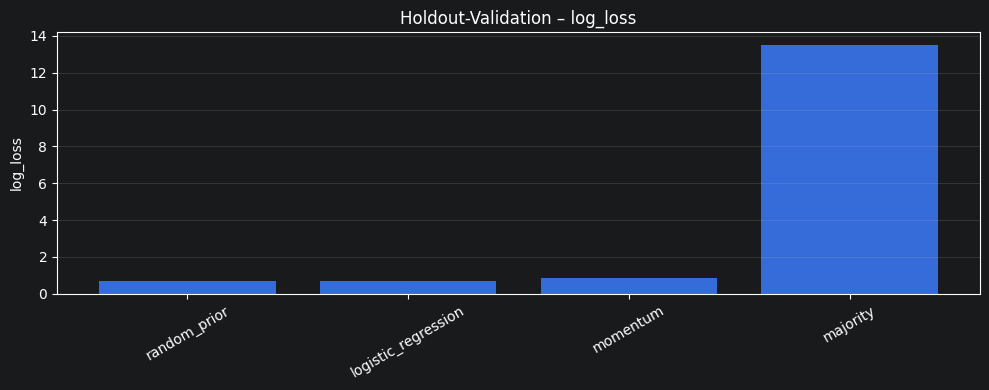

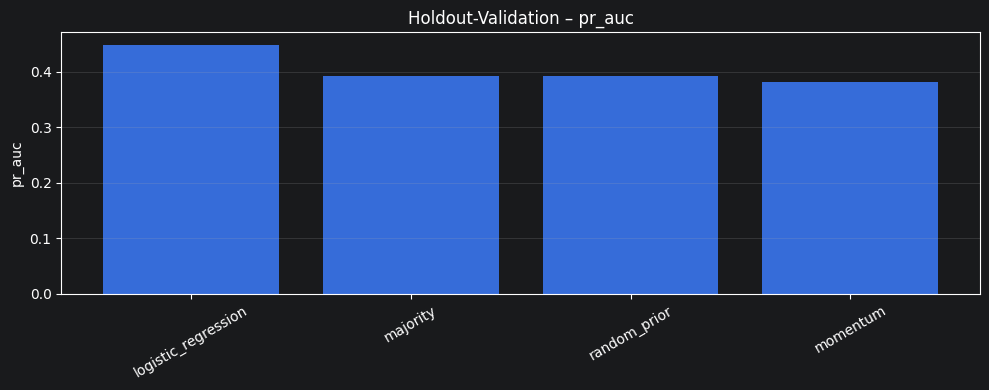

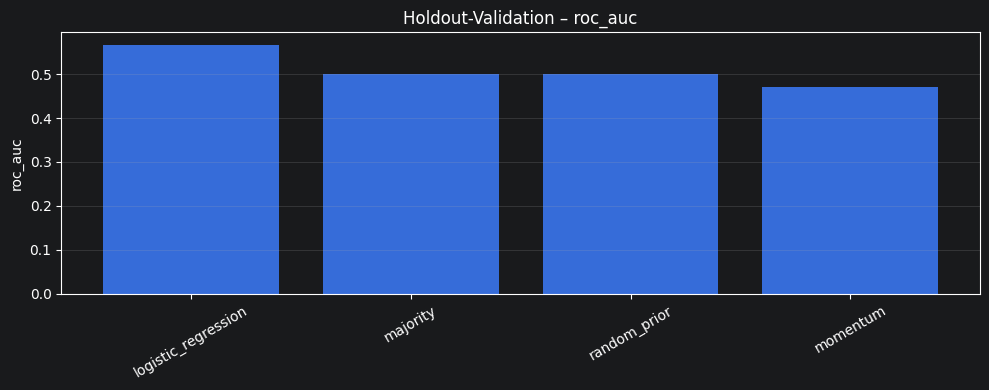

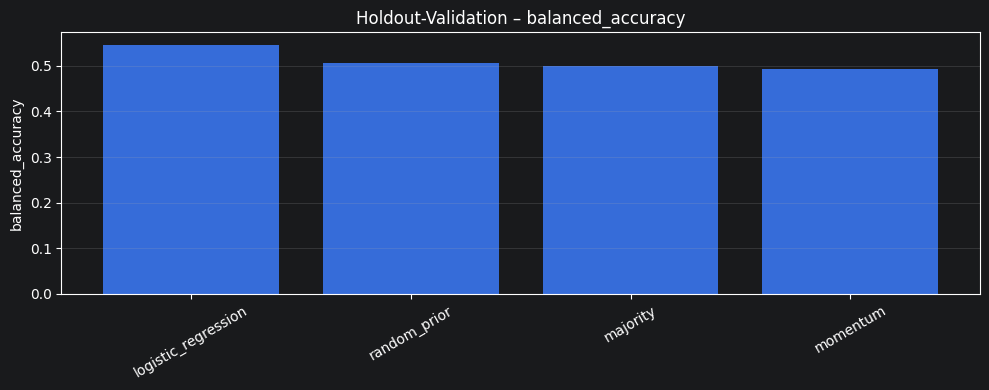

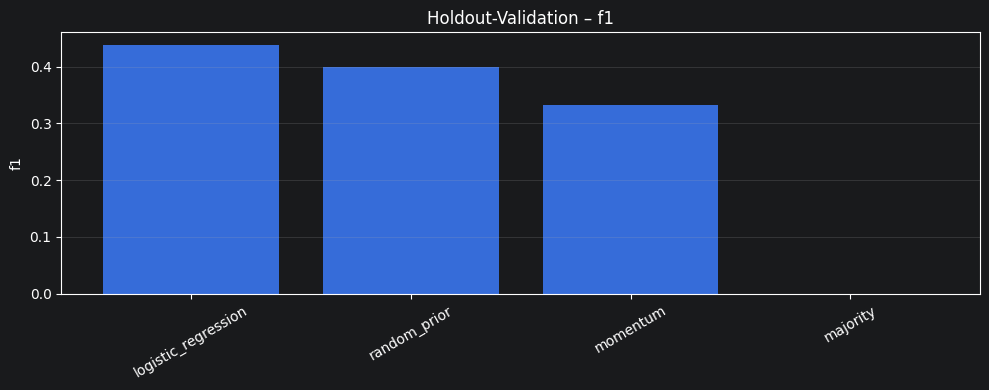

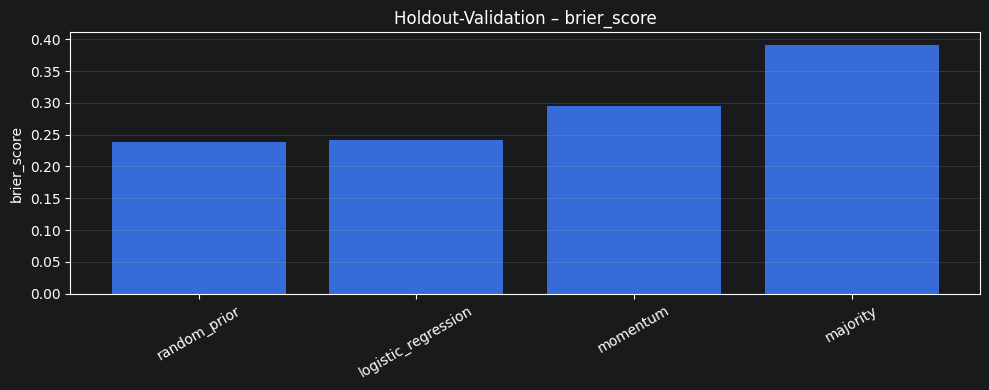

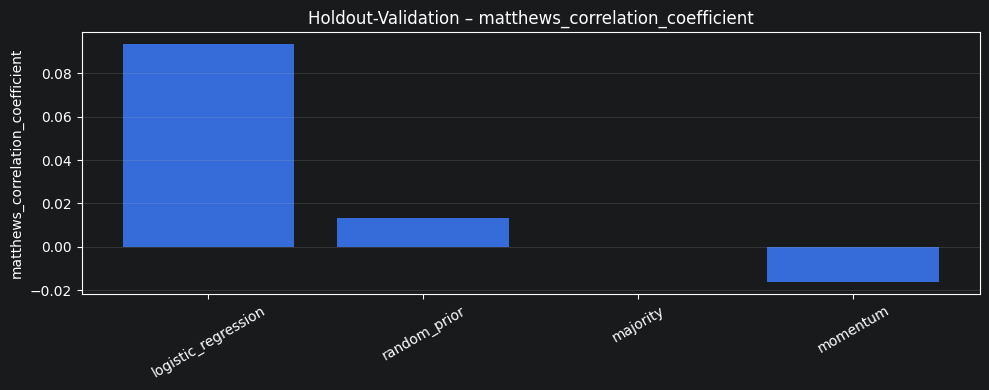

In [11]:
if resolved_task in CLASSIFICATION_TASKS:
    preferred_metrics = [
        "log_loss",
        "pr_auc",
        "roc_auc",
        "balanced_accuracy",
        "f1",
        "brier_score",
        "matthews_correlation_coefficient",
    ]
else:
    preferred_metrics = [
        "rmse",
        "mae",
        "mase",
        "r2",
        "directional_accuracy",
        "pearson",
        "spearman",
    ]

lower_is_better_metrics = {
    "log_loss",
    "brier_score",
    "rmse",
    "mae",
    "mase",
    "mse",
    "median_absolute_error",
}

available_metrics = [
    metric
    for metric in preferred_metrics
    if metric in holdout_pivot.columns
]

for metric in available_metrics:
    values = (
        holdout_pivot[metric]
        .dropna()
        .sort_values(
            ascending=(
                metric
                in lower_is_better_metrics
            )
        )
    )

    figure, axis = plt.subplots(
        figsize=(10, 4)
    )
    axis.bar(
        values.index,
        values.values,
    )
    axis.set_title(
        f"Holdout-Validation – {metric}"
    )
    axis.set_ylabel(metric)
    axis.tick_params(
        axis="x",
        rotation=30,
    )
    axis.grid(
        True,
        axis="y",
        alpha=0.25,
    )
    figure.tight_layout()
    display(figure)
    plt.close(figure)

## 12. Walk-Forward-Foldmetriken

In [12]:
if EVALUATE_CV:
    if fold_metrics.empty:
        raise RuntimeError(
            "Cross-Validation ist aktiviert, aber "
            "fold_metrics.csv ist leer."
        )

    fold_pivot = (
        fold_metrics
        .pivot_table(
            index=["fold", "model"],
            columns="metric",
            values="value",
            aggfunc="first",
        )
        .reset_index()
    )
    display(fold_pivot.head(40))
else:
    fold_pivot = pd.DataFrame()
    print("Cross-Validation wurde deaktiviert.")

metric,fold,model,accuracy,balanced_accuracy,brier_score,f1,log_loss,matthews_correlation_coefficient,pr_auc,precision,recall,roc_auc
0,fold_01,logistic_regression,0.663349,0.564722,0.223011,0.362386,0.637836,0.138743,0.386707,0.406064,0.327193,0.606641
1,fold_01,majority,0.707611,0.500000,0.292389,0.000000,10.098750,0.000000,0.292389,0.000000,0.000000,0.500000
2,fold_01,momentum,0.643443,0.513291,0.242358,0.246846,0.704766,0.031401,0.296165,0.322768,0.199840,0.469926
3,fold_01,random_prior,0.544848,0.505898,0.218487,0.346173,0.629397,0.010936,0.292389,0.298434,0.412095,0.500000
4,fold_02,logistic_regression,0.692037,0.565643,0.216991,0.337865,0.625417,0.146505,0.364218,0.400119,0.292375,0.611763
5,fold_02,majority,0.731265,0.500000,0.268735,0.000000,9.281791,0.000000,0.268735,0.000000,0.000000,0.500000
6,fold_02,momentum,0.664286,0.508497,0.234903,0.215595,0.684865,0.020588,0.266032,0.289706,0.171678,0.461102
7,fold_02,random_prior,0.543677,0.496861,0.213502,0.317872,0.619277,-0.005681,0.268735,0.265652,0.395643,0.500000
8,fold_03,logistic_regression,0.694262,0.550406,0.212888,0.276932,0.616499,0.138298,0.400256,0.461681,0.197785,0.619975
9,fold_03,majority,0.703981,0.500000,0.296019,0.000000,10.224125,0.000000,0.296019,0.000000,0.000000,0.500000


## 13. Aggregierte Cross-Validation

In [13]:
if EVALUATE_CV:
    if aggregate_metrics.empty:
        aggregate_metrics = (
            aggregate_cv_metrics(
                fold_metrics
            )
        )

    aggregate_pivot = (
        aggregate_metrics
        .pivot_table(
            index="model",
            columns="metric",
            values="mean",
            aggfunc="first",
        )
        .sort_index()
    )
    cv_variability = (
        aggregate_metrics
        .pivot_table(
            index="model",
            columns="metric",
            values="std",
            aggfunc="first",
        )
        .sort_index()
    )

    display(
        Markdown(
            "### Mittelwerte über alle Folds"
        )
    )
    display(aggregate_pivot)

    display(
        Markdown(
            "### Standardabweichungen zwischen Folds"
        )
    )
    display(cv_variability)
else:
    aggregate_pivot = pd.DataFrame()
    cv_variability = pd.DataFrame()

### Mittelwerte über alle Folds

metric,accuracy,balanced_accuracy,brier_score,f1,log_loss,matthews_correlation_coefficient,pr_auc,precision,recall,roc_auc
model,,,,,,,,,,
logistic_regression,0.664637,0.550716,0.221111,0.305647,0.633709,0.124508,0.402576,0.442001,0.242076,0.605864
majority,0.687073,0.500000,0.312927,0.000000,10.808130,0.000000,0.312927,0.000000,0.000000,0.500000
momentum,0.623162,0.510571,0.251316,0.262967,0.729983,0.024792,0.313117,0.336515,0.216091,0.470881
random_prior,0.537705,0.500486,0.222111,0.350634,0.636716,0.000964,0.312927,0.313509,0.400813,0.500000


### Standardabweichungen zwischen Folds

metric,accuracy,balanced_accuracy,brier_score,f1,log_loss,matthews_correlation_coefficient,pr_auc,precision,recall,roc_auc
model,,,,,,,,,,
logistic_regression,0.031867,0.014435,0.006982,0.045741,0.014487,0.024650,0.029158,0.036931,0.066374,0.012338
majority,0.040177,0.000000,0.040177,0.000000,1.387648,0.000000,0.040177,0.000000,0.000000,0.000000
momentum,0.040310,0.006018,0.015642,0.035330,0.040930,0.014356,0.038397,0.032471,0.034450,0.006311
random_prior,0.008217,0.004561,0.007878,0.025744,0.015961,0.008564,0.040177,0.041086,0.006503,0.000000


## 14. Stabilität der Selektionsmetrik

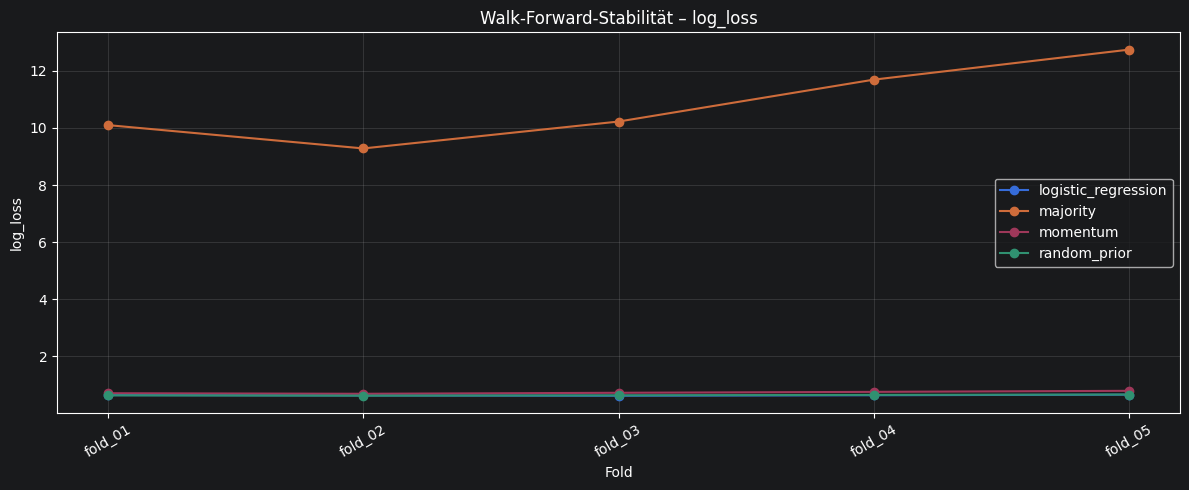

,phase,fold,task,horizon,target_column,model,train_rows,evaluation_rows,metric,value
0,cross_validation,fold_01,binary_classification,4,target_binary_4,logistic_regression,117828,8540,log_loss,0.637836
1,cross_validation,fold_02,binary_classification,4,target_binary_4,logistic_regression,120708,8540,log_loss,0.625417
2,cross_validation,fold_03,binary_classification,4,target_binary_4,logistic_regression,123588,8540,log_loss,0.616499
3,cross_validation,fold_04,binary_classification,4,target_binary_4,logistic_regression,126468,8540,log_loss,0.633695
4,cross_validation,fold_05,binary_classification,4,target_binary_4,logistic_regression,129348,8540,log_loss,0.655099
5,cross_validation,fold_01,binary_classification,4,target_binary_4,majority,117828,8540,log_loss,10.098750
6,cross_validation,fold_02,binary_classification,4,target_binary_4,majority,120708,8540,log_loss,9.281791
7,cross_validation,fold_03,binary_classification,4,target_binary_4,majority,123588,8540,log_loss,10.224125
8,cross_validation,fold_04,binary_classification,4,target_binary_4,majority,126468,8540,log_loss,11.692225
9,cross_validation,fold_05,binary_classification,4,target_binary_4,majority,129348,8540,log_loss,12.743757


In [14]:
selection_metric = str(
    summary.get(
        "selection_metric",
        (
            "log_loss"
            if resolved_task
            in CLASSIFICATION_TASKS
            else "rmse"
        ),
    )
)

if EVALUATE_CV:
    selection_rows = (
        fold_metrics.loc[
            fold_metrics["metric"]
            == selection_metric
        ]
        .copy()
    )

    figure, axis = plt.subplots(
        figsize=(12, 5)
    )

    for model, group in (
        selection_rows.groupby(
            "model",
            observed=True,
        )
    ):
        ordered = group.sort_values(
            "fold"
        )
        axis.plot(
            ordered["fold"],
            ordered["value"],
            marker="o",
            label=model,
        )

    axis.set_title(
        f"Walk-Forward-Stabilität – "
        f"{selection_metric}"
    )
    axis.set_xlabel("Fold")
    axis.set_ylabel(selection_metric)
    axis.tick_params(
        axis="x",
        rotation=30,
    )
    axis.grid(True, alpha=0.25)
    axis.legend()
    figure.tight_layout()
    display(figure)
    plt.close(figure)

    display(
        selection_rows
        .sort_values(
            ["model", "fold"]
        )
        .reset_index(drop=True)
    )

## 15. Holdout- und CV-Rangfolge

In [15]:
lower_is_better = (
    selection_metric
    in lower_is_better_metrics
)

holdout_selection = (
    holdout_metrics.loc[
        holdout_metrics["metric"]
        == selection_metric,
        ["model", "value"],
    ]
    .rename(
        columns={
            "value": "holdout_value",
        }
    )
)

if EVALUATE_CV:
    cv_selection = (
        aggregate_metrics.loc[
            aggregate_metrics["metric"]
            == selection_metric,
            ["model", "mean", "std"],
        ]
        .rename(
            columns={
                "mean": "cv_mean",
                "std": "cv_std",
            }
        )
    )
else:
    cv_selection = pd.DataFrame(
        columns=[
            "model",
            "cv_mean",
            "cv_std",
        ]
    )

model_ranking = holdout_selection.merge(
    cv_selection,
    on="model",
    how="left",
    validate="one_to_one",
)

model_ranking["holdout_rank"] = (
    model_ranking["holdout_value"]
    .rank(
        ascending=lower_is_better,
        method="min",
    )
)

if model_ranking["cv_mean"].notna().any():
    model_ranking["cv_rank"] = (
        model_ranking["cv_mean"]
        .rank(
            ascending=lower_is_better,
            method="min",
        )
    )
    model_ranking["rank_difference"] = (
        model_ranking["holdout_rank"]
        - model_ranking["cv_rank"]
    )

display(
    model_ranking
    .sort_values("holdout_rank")
    .reset_index(drop=True)
)

,model,holdout_value,cv_mean,cv_std,holdout_rank,cv_rank,rank_difference
0,random_prior,0.669317,0.636716,0.015961,1.000000,2.000000,-1.000000
1,logistic_regression,0.677582,0.633709,0.014487,2.000000,1.000000,1.000000
2,momentum,0.870268,0.729983,0.040930,3.000000,3.000000,0.000000
3,majority,13.513459,10.808130,1.387648,4.000000,4.000000,0.000000


## 16. Bestes Baseline-Modell reproduzieren

In [16]:
best_holdout_model = select_best_model(
    holdout_metrics,
    metric=selection_metric,
    aggregate_column="value",
)

if EVALUATE_CV:
    best_cv_model = select_best_model(
        aggregate_metrics,
        metric=selection_metric,
        aggregate_column="mean",
    )
else:
    best_cv_model = None

display(
    pd.DataFrame(
        [
            {
                "selection_metric": (
                    selection_metric
                ),
                "lower_is_better": (
                    lower_is_better
                ),
                "computed_best_holdout": (
                    best_holdout_model
                ),
                "saved_best_holdout": (
                    summary.get(
                        "best_holdout_model"
                    )
                ),
                "computed_best_cv": (
                    best_cv_model
                ),
                "saved_best_cv": (
                    summary.get(
                        "best_cv_model"
                    )
                ),
            }
        ]
    )
)

assert (
    best_holdout_model
    == summary.get("best_holdout_model")
)

if EVALUATE_CV:
    assert (
        best_cv_model
        == summary.get("best_cv_model")
    )

,selection_metric,lower_is_better,computed_best_holdout,saved_best_holdout,computed_best_cv,saved_best_cv
0,log_loss,True,random_prior,random_prior,logistic_regression,logistic_regression


## 17. Konfusionsmatrizen

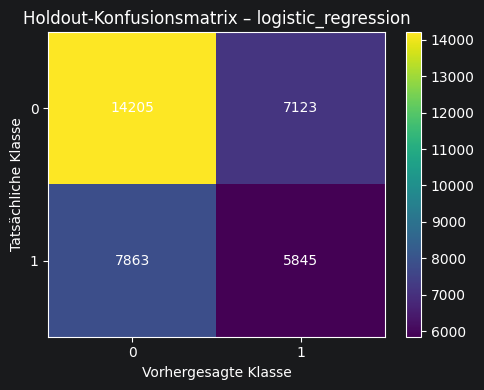

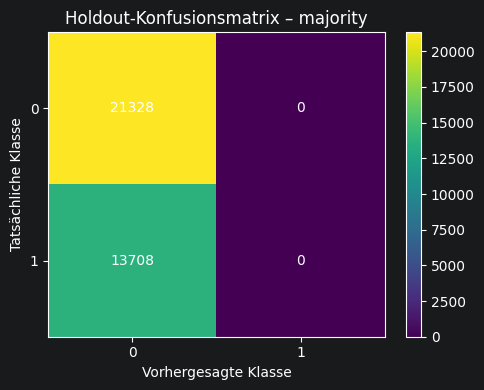

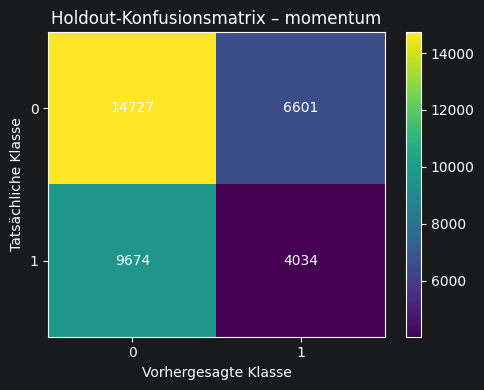

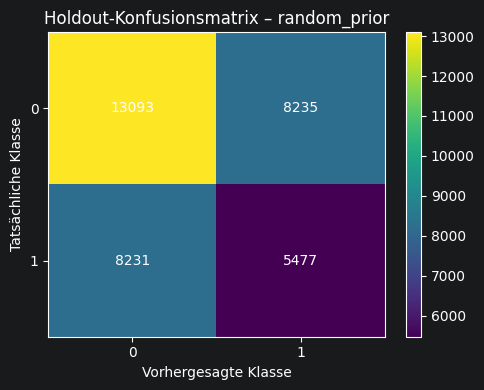

In [17]:
if resolved_task in CLASSIFICATION_TASKS:
    holdout_confusion = (
        confusion_matrices.loc[
            confusion_matrices["phase"]
            == "holdout_validation"
        ]
        .copy()
    )

    for model, group in (
        holdout_confusion.groupby(
            "model",
            observed=True,
        )
    ):
        classes = sorted(
            set(group["actual_class"])
            | set(group["predicted_class"])
        )

        matrix = (
            group
            .pivot_table(
                index="actual_class",
                columns="predicted_class",
                values="count",
                aggfunc="sum",
                fill_value=0,
            )
            .reindex(
                index=classes,
                columns=classes,
                fill_value=0,
            )
        )

        figure, axis = plt.subplots(
            figsize=(5, 4)
        )
        image = axis.imshow(
            matrix.to_numpy(),
            aspect="auto",
        )
        axis.set_xticks(
            range(len(classes))
        )
        axis.set_xticklabels(classes)
        axis.set_yticks(
            range(len(classes))
        )
        axis.set_yticklabels(classes)
        axis.set_xlabel(
            "Vorhergesagte Klasse"
        )
        axis.set_ylabel(
            "Tatsächliche Klasse"
        )
        axis.set_title(
            f"Holdout-Konfusionsmatrix – "
            f"{model}"
        )

        for row_index in range(
            len(classes)
        ):
            for column_index in range(
                len(classes)
            ):
                axis.text(
                    column_index,
                    row_index,
                    int(
                        matrix.iloc[
                            row_index,
                            column_index,
                        ]
                    ),
                    ha="center",
                    va="center",
                )

        figure.colorbar(image, ax=axis)
        figure.tight_layout()
        display(figure)
        plt.close(figure)

## 18. Klassenspezifische Precision und Recall

In [18]:
if resolved_task in CLASSIFICATION_TASKS:
    class_metric_rows = []

    holdout_confusion = (
        confusion_matrices.loc[
            confusion_matrices["phase"]
            == "holdout_validation"
        ]
    )

    for model, group in (
        holdout_confusion.groupby(
            "model",
            observed=True,
        )
    ):
        classes = sorted(
            set(group["actual_class"])
            | set(group["predicted_class"])
        )
        matrix = (
            group
            .pivot_table(
                index="actual_class",
                columns="predicted_class",
                values="count",
                aggfunc="sum",
                fill_value=0,
            )
            .reindex(
                index=classes,
                columns=classes,
                fill_value=0,
            )
        )

        for class_value in classes:
            true_positive = float(
                matrix.loc[
                    class_value,
                    class_value,
                ]
            )
            predicted_positive = float(
                matrix[class_value].sum()
            )
            actual_positive = float(
                matrix.loc[
                    class_value
                ].sum()
            )

            class_metric_rows.append(
                {
                    "model": model,
                    "class": class_value,
                    "precision": (
                        true_positive
                        / predicted_positive
                        if predicted_positive
                        else np.nan
                    ),
                    "recall": (
                        true_positive
                        / actual_positive
                        if actual_positive
                        else np.nan
                    ),
                    "support": int(
                        actual_positive
                    ),
                }
            )

    class_metrics = pd.DataFrame(
        class_metric_rows
    )
    display(class_metrics)

,model,class,precision,recall,support
0,logistic_regression,0,0.643692,0.666026,21328
1,logistic_regression,1,0.450725,0.426393,13708
2,majority,0,0.608745,1.000000,21328
3,majority,1,NaN,0.000000,13708
4,momentum,0,0.603541,0.690501,21328
5,momentum,1,0.379314,0.294281,13708
6,random_prior,0,0.614003,0.613888,21328
7,random_prior,1,0.399431,0.399548,13708


## 19. Wahrscheinlichkeitskalibrierung

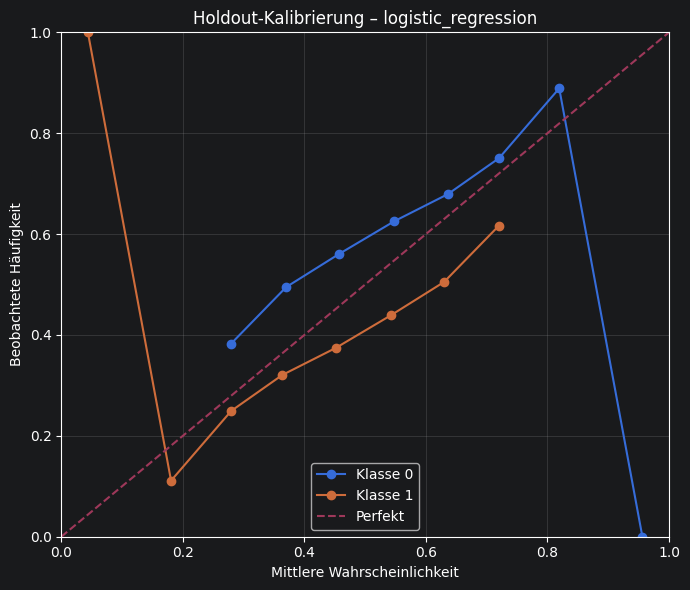

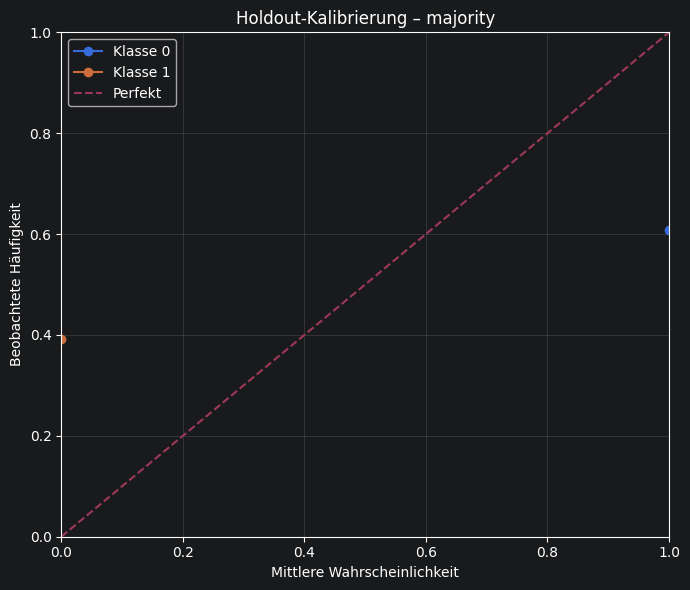

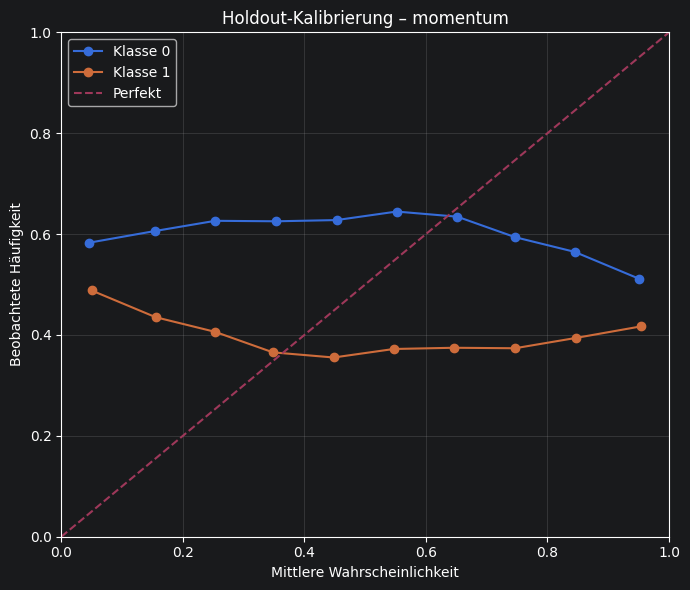

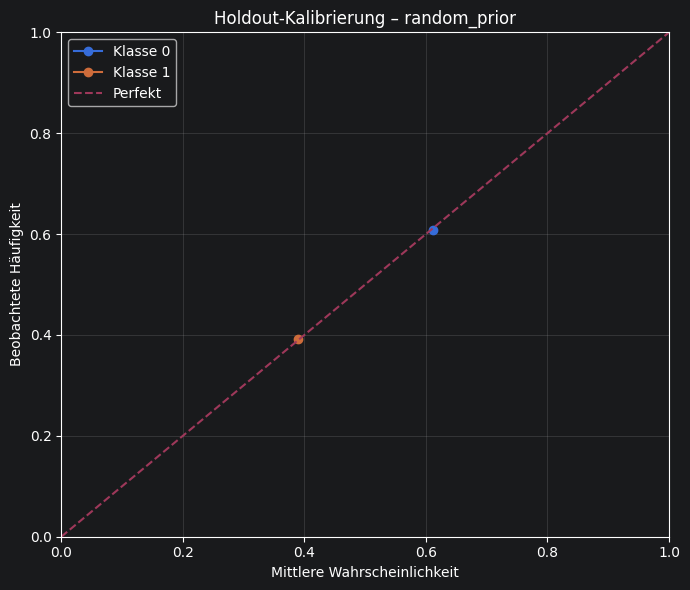

In [19]:
if (
    resolved_task in CLASSIFICATION_TASKS
    and not probability_calibration.empty
):
    holdout_calibration = (
        probability_calibration.loc[
            (
                probability_calibration[
                    "phase"
                ]
                == "holdout_validation"
            )
            & (
                probability_calibration[
                    "count"
                ]
                > 0
            )
        ]
        .copy()
    )

    for model, model_group in (
        holdout_calibration.groupby(
            "model",
            observed=True,
        )
    ):
        figure, axis = plt.subplots(
            figsize=(7, 6)
        )

        for class_value, class_group in (
            model_group.groupby(
                "class",
                observed=True,
            )
        ):
            ordered = class_group.sort_values(
                "mean_probability"
            )
            axis.plot(
                ordered[
                    "mean_probability"
                ],
                ordered[
                    "observed_frequency"
                ],
                marker="o",
                label=(
                    f"Klasse {class_value}"
                ),
            )

        axis.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            label="Perfekt",
        )
        axis.set_xlim(0, 1)
        axis.set_ylim(0, 1)
        axis.set_xlabel(
            "Mittlere Wahrscheinlichkeit"
        )
        axis.set_ylabel(
            "Beobachtete Häufigkeit"
        )
        axis.set_title(
            f"Holdout-Kalibrierung – "
            f"{model}"
        )
        axis.grid(True, alpha=0.25)
        axis.legend()
        figure.tight_layout()
        display(figure)
        plt.close(figure)

## 20. Expected Calibration Error

In [20]:
if (
    resolved_task in CLASSIFICATION_TASKS
    and not probability_calibration.empty
):
    usable_calibration = (
        probability_calibration.loc[
            (
                probability_calibration[
                    "phase"
                ]
                == "holdout_validation"
            )
            & (
                probability_calibration[
                    "count"
                ]
                > 0
            )
        ]
        .copy()
    )

    calibration_error_rows = []

    for (
        model,
        class_value,
    ), group in usable_calibration.groupby(
        ["model", "class"],
        observed=True,
    ):
        total = float(
            group["count"].sum()
        )
        absolute_gap = (
            group["mean_probability"]
            - group[
                "observed_frequency"
            ]
        ).abs()

        calibration_error_rows.append(
            {
                "model": model,
                "class": class_value,
                "expected_calibration_error": (
                    float(
                        (
                            absolute_gap
                            * group["count"]
                        ).sum()
                        / total
                    )
                ),
                "observations": int(total),
            }
        )

    calibration_errors = pd.DataFrame(
        calibration_error_rows
    )
    display(
        calibration_errors
        .sort_values(
            ["model", "class"]
        )
        .reset_index(drop=True)
    )

,model,class,expected_calibration_error,observations
0,logistic_regression,0,0.081532,35036
1,logistic_regression,1,0.081532,35036
2,majority,0,0.391255,35036
3,majority,1,0.391255,35036
4,momentum,0,0.194234,35036
5,momentum,1,0.194234,35036
6,random_prior,0,0.002315,35036
7,random_prior,1,0.002315,35036


## 21. Vorhersageverteilungen

,phase,fold,task,horizon,target_column,model,distribution,value,count,ratio
0,holdout_validation,NaN,binary_classification,4,target_binary_4,logistic_regression,predicted,0.000000,22068,0.629866
1,holdout_validation,NaN,binary_classification,4,target_binary_4,logistic_regression,predicted,1.000000,12968,0.370134
2,holdout_validation,NaN,binary_classification,4,target_binary_4,logistic_regression,true,0.000000,21328,0.608745
3,holdout_validation,NaN,binary_classification,4,target_binary_4,logistic_regression,true,1.000000,13708,0.391255
4,holdout_validation,NaN,binary_classification,4,target_binary_4,majority,predicted,0.000000,35036,1.000000
5,holdout_validation,NaN,binary_classification,4,target_binary_4,majority,true,0.000000,21328,0.608745
6,holdout_validation,NaN,binary_classification,4,target_binary_4,majority,true,1.000000,13708,0.391255
7,holdout_validation,NaN,binary_classification,4,target_binary_4,momentum,predicted,0.000000,24401,0.696455
8,holdout_validation,NaN,binary_classification,4,target_binary_4,momentum,predicted,1.000000,10635,0.303545
9,holdout_validation,NaN,binary_classification,4,target_binary_4,momentum,true,0.000000,21328,0.608745


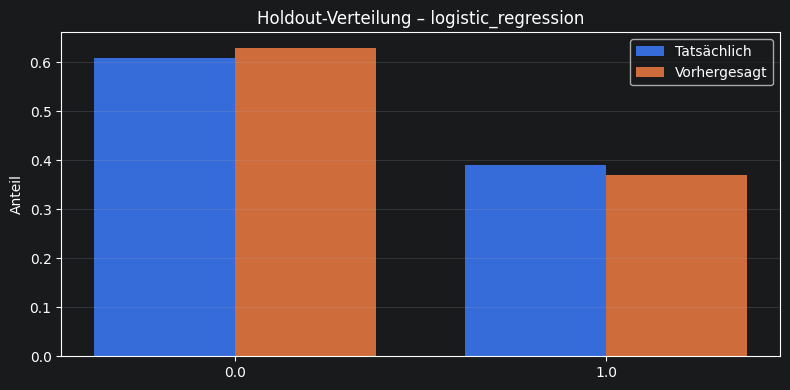

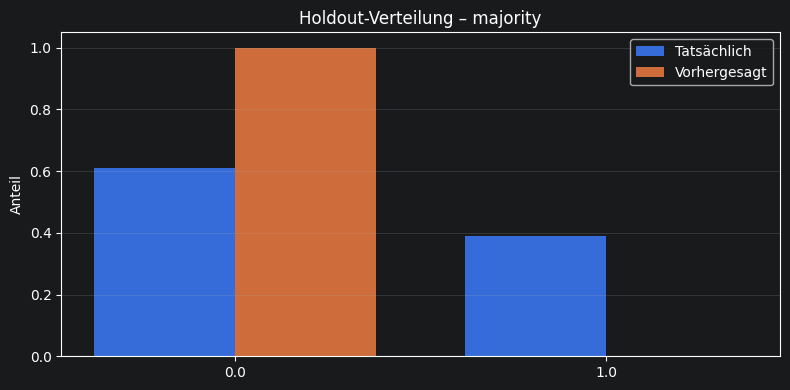

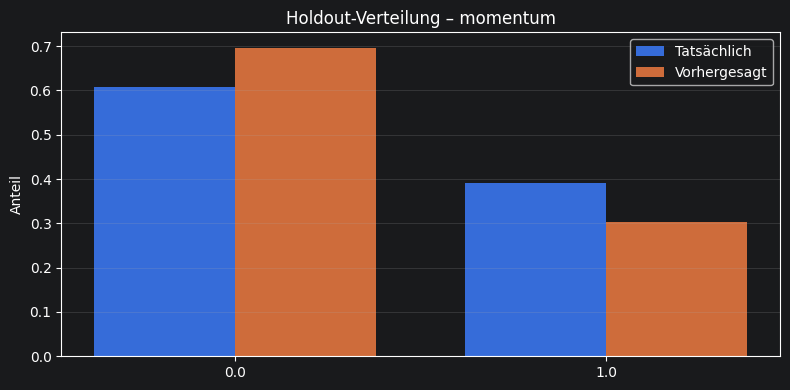

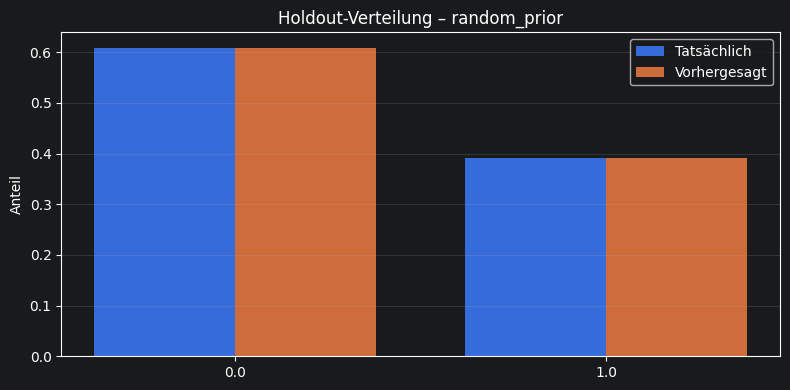

In [21]:
if not prediction_distribution.empty:
    holdout_distribution = (
        prediction_distribution.loc[
            prediction_distribution[
                "phase"
            ]
            == "holdout_validation"
        ]
        .copy()
    )

    display(
        holdout_distribution
        .sort_values(
            [
                "model",
                "distribution",
                "value",
            ]
        )
        .reset_index(drop=True)
    )

    for model, group in (
        holdout_distribution.groupby(
            "model",
            observed=True,
        )
    ):
        pivot = (
            group
            .pivot_table(
                index="value",
                columns="distribution",
                values="ratio",
                aggfunc="sum",
                fill_value=0,
            )
            .sort_index()
        )

        figure, axis = plt.subplots(
            figsize=(8, 4)
        )
        positions = np.arange(
            len(pivot)
        )
        width = 0.38

        if "true" in pivot.columns:
            axis.bar(
                positions - width / 2,
                pivot["true"],
                width=width,
                label="Tatsächlich",
            )

        if "predicted" in pivot.columns:
            axis.bar(
                positions + width / 2,
                pivot["predicted"],
                width=width,
                label="Vorhergesagt",
            )

        axis.set_xticks(positions)
        axis.set_xticklabels(
            pivot.index
        )
        axis.set_title(
            f"Holdout-Verteilung – "
            f"{model}"
        )
        axis.set_ylabel("Anteil")
        axis.grid(
            True,
            axis="y",
            alpha=0.25,
        )
        axis.legend()
        figure.tight_layout()
        display(figure)
        plt.close(figure)

## 22. Lineare Koeffizienten

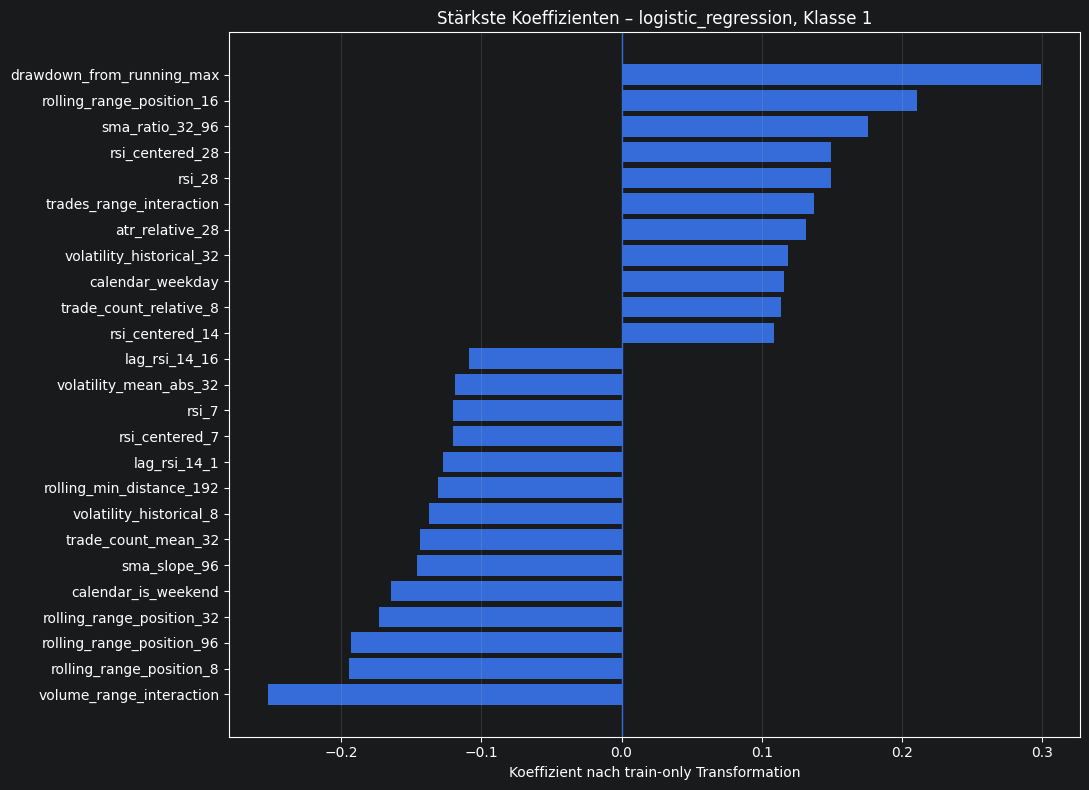

,feature,coefficient,absolute_coefficient
0,drawdown_from_running_max,0.299620,0.299620
1,volume_range_interaction,-0.252400,0.252400
2,rolling_range_position_16,0.211027,0.211027
3,rolling_range_position_8,-0.194761,0.194761
4,rolling_range_position_96,-0.193246,0.193246
5,sma_ratio_32_96,0.176094,0.176094
6,rolling_range_position_32,-0.172878,0.172878
7,calendar_is_weekend,-0.164620,0.164620
8,rsi_centered_28,0.149656,0.149656
9,rsi_28,0.149656,0.149656


In [22]:
if not feature_coefficients.empty:
    coefficient_phase = (
        feature_coefficients.loc[
            feature_coefficients[
                "phase"
            ]
            == "holdout_validation"
        ]
        .copy()
    )

    for (
        model,
        class_value,
    ), group in coefficient_phase.groupby(
        ["model", "class"],
        observed=True,
    ):
        strongest = (
            group
            .sort_values(
                "absolute_coefficient",
                ascending=False,
            )
            .head(25)
            .sort_values("coefficient")
        )

        figure, axis = plt.subplots(
            figsize=(11, 8)
        )
        axis.barh(
            strongest["feature"],
            strongest["coefficient"],
        )
        axis.axvline(0, linewidth=1)
        axis.set_title(
            f"Stärkste Koeffizienten – "
            f"{model}, Klasse {class_value}"
        )
        axis.set_xlabel(
            "Koeffizient nach "
            "train-only Transformation"
        )
        axis.grid(
            True,
            axis="x",
            alpha=0.25,
        )
        figure.tight_layout()
        display(figure)
        plt.close(figure)

        display(
            strongest[
                [
                    "feature",
                    "coefficient",
                    "absolute_coefficient",
                ]
            ]
            .sort_values(
                "absolute_coefficient",
                ascending=False,
            )
            .reset_index(drop=True)
        )
else:
    print(
        "Keine Koeffizienten gespeichert."
    )

## 23. Koeffizienten nach Featuregruppe

In [23]:
def feature_group(
    feature: str,
) -> str:
    if feature.startswith("lag_"):
        return "Lags"
    if feature.startswith("calendar_"):
        return "Kalender"
    if feature.startswith(
        ("regime_", "drawdown_")
    ):
        return "Regime"
    if feature.startswith(
        (
            "volatility_",
            "atr_",
            "parkinson_",
            "garman_klass_",
            "true_range_",
            "return_squared_",
            "return_absolute_",
        )
    ):
        return "Volatilität"
    if feature.startswith(
        (
            "volume_",
            "quote_volume_",
            "trade_count_",
            "taker_",
            "average_volume_",
            "average_quote_",
        )
    ):
        return "Volumen und Trades"
    if feature.startswith(
        (
            "sma_",
            "ema_",
            "close_to_",
            "rolling_",
            "rsi_",
            "roc_",
            "bollinger_",
            "macd_",
            "adx_",
            "plus_di_",
            "minus_di_",
            "directional_",
        )
    ):
        return "Trend"
    if feature.startswith(
        (
            "candle_",
            "upper_wick_",
            "lower_wick_",
            "close_location",
            "body_to_",
            "is_",
            "open_gap_",
            "gap_",
        )
    ):
        return "Candle und Gap"
    if feature.startswith(
        ("return_", "momentum_")
    ):
        return "Rendite und Momentum"
    return "Sonstige"


if not feature_coefficients.empty:
    grouped_coefficients = (
        feature_coefficients.loc[
            feature_coefficients[
                "phase"
            ]
            == "holdout_validation"
        ]
        .copy()
    )
    grouped_coefficients[
        "feature_group"
    ] = grouped_coefficients[
        "feature"
    ].map(feature_group)

    coefficient_group_summary = (
        grouped_coefficients
        .groupby(
            [
                "model",
                "class",
                "feature_group",
            ],
            observed=True,
        )
        .agg(
            feature_count=(
                "feature",
                "count",
            ),
            mean_absolute_coefficient=(
                "absolute_coefficient",
                "mean",
            ),
            maximum_absolute_coefficient=(
                "absolute_coefficient",
                "max",
            ),
        )
        .reset_index()
        .sort_values(
            [
                "model",
                "class",
                "mean_absolute_coefficient",
            ],
            ascending=[
                True,
                True,
                False,
            ],
        )
    )

    display(
        coefficient_group_summary
    )

,model,class,feature_group,feature_count,mean_absolute_coefficient,maximum_absolute_coefficient
5,logistic_regression,1,Sonstige,1,0.137464,0.137464
1,logistic_regression,1,Kalender,13,0.064121,0.164620
3,logistic_regression,1,Regime,19,0.054544,0.299620
7,logistic_regression,1,Volatilität,41,0.044826,0.137346
6,logistic_regression,1,Trend,98,0.044195,0.211027
8,logistic_regression,1,Volumen und Trades,68,0.032209,0.252400
0,logistic_regression,1,Candle und Gap,15,0.022543,0.099472
4,logistic_regression,1,Rendite und Momentum,28,0.021005,0.057343
2,logistic_regression,1,Lags,50,0.018204,0.127358


## 24. Verbesserung gegenüber naiver Baseline

In [24]:
if resolved_task in CLASSIFICATION_TASKS:
    naive_model = (
        "majority"
        if "majority"
        in holdout_pivot.index
        else holdout_pivot.index[0]
    )
else:
    naive_model = (
        "zero"
        if "zero"
        in holdout_pivot.index
        else holdout_pivot.index[0]
    )

improvement_rows = []

for metric in available_metrics:
    naive_value = holdout_pivot.loc[
        naive_model,
        metric,
    ]

    for model in holdout_pivot.index:
        model_value = holdout_pivot.loc[
            model,
            metric,
        ]

        if (
            pd.isna(naive_value)
            or pd.isna(model_value)
        ):
            continue

        metric_lower_is_better = (
            metric
            in lower_is_better_metrics
        )

        absolute_improvement = (
            naive_value - model_value
            if metric_lower_is_better
            else model_value - naive_value
        )

        improvement_rows.append(
            {
                "metric": metric,
                "naive_model": naive_model,
                "model": model,
                "naive_value": naive_value,
                "model_value": model_value,
                "absolute_improvement": (
                    absolute_improvement
                ),
                "relative_improvement": (
                    absolute_improvement
                    / abs(naive_value)
                    if abs(naive_value)
                    > 1e-15
                    else np.nan
                ),
            }
        )

baseline_improvements = pd.DataFrame(
    improvement_rows
)

display(
    baseline_improvements
    .sort_values(
        [
            "metric",
            "absolute_improvement",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

,metric,naive_model,model,naive_value,model_value,absolute_improvement,relative_improvement
0,balanced_accuracy,majority,logistic_regression,0.500000,0.546210,0.046210,0.092419
1,balanced_accuracy,majority,random_prior,0.500000,0.506718,0.006718,0.013436
2,balanced_accuracy,majority,majority,0.500000,0.500000,0.000000,0.000000
3,balanced_accuracy,majority,momentum,0.500000,0.492391,-0.007609,-0.015219
4,brier_score,majority,random_prior,0.391255,0.238180,0.153075,0.391241
5,brier_score,majority,logistic_regression,0.391255,0.242316,0.148939,0.380670
6,brier_score,majority,momentum,0.391255,0.295683,0.095571,0.244269
7,brier_score,majority,majority,0.391255,0.391255,0.000000,0.000000
8,f1,majority,logistic_regression,0.000000,0.438222,0.438222,NaN
9,f1,majority,random_prior,0.000000,0.399489,0.399489,NaN


## 25. Generalisierungslücke

In [25]:
if EVALUATE_CV:
    generalization_table = (
        model_ranking.copy()
    )
    generalization_table[
        "holdout_minus_cv"
    ] = (
        generalization_table[
            "holdout_value"
        ]
        - generalization_table["cv_mean"]
    )

    display(
        generalization_table
        .sort_values("holdout_rank")
        .reset_index(drop=True)
    )

,model,holdout_value,cv_mean,cv_std,holdout_rank,cv_rank,rank_difference,holdout_minus_cv
0,random_prior,0.669317,0.636716,0.015961,1.000000,2.000000,-1.000000,0.032602
1,logistic_regression,0.677582,0.633709,0.014487,2.000000,1.000000,1.000000,0.043873
2,momentum,0.870268,0.729983,0.040930,3.000000,3.000000,0.000000,0.140285
3,majority,13.513459,10.808130,1.387648,4.000000,4.000000,0.000000,2.705329


## 26. Manifest und Reproduzierbarkeit

In [26]:
reproducibility_checks = pd.DataFrame(
    [
        {
            "check": (
                "Transformer nur auf Training"
            ),
            "passed": (
                manifest.get(
                    "transformers_fit_on_training_only"
                )
                is True
            ),
        },
        {
            "check": (
                "Keine zufällige Mischung"
            ),
            "passed": (
                manifest.get(
                    "shuffle_applied"
                )
                is False
            ),
        },
        {
            "check": (
                "Keine Stratifizierung"
            ),
            "passed": (
                manifest.get(
                    "stratification_applied"
                )
                is False
            ),
        },
        {
            "check": (
                "Test nicht für Modellauswahl"
            ),
            "passed": (
                manifest.get(
                    "test_used_for_model_selection"
                )
                is False
            ),
        },
        {
            "check": (
                "Konfigurationshash vorhanden"
            ),
            "passed": bool(
                manifest.get(
                    "configuration_hash"
                )
            ),
        },
        {
            "check": (
                "Featureliste vollständig"
            ),
            "passed": (
                len(
                    manifest.get(
                        "feature_columns",
                        [],
                    )
                )
                == input_report.feature_count
            ),
        },
    ]
)

display(reproducibility_checks)

,check,passed
0,Transformer nur auf Training,True
1,Keine zufällige Mischung,True
2,Keine Stratifizierung,True
3,Test nicht für Modellauswahl,True
4,Konfigurationshash vorhanden,True
5,Featureliste vollständig,True


## 27. Gespeicherte Modellartefakte

In [27]:
artifact_paths = {
    **summary.get(
        "artifact_paths",
        {}
    ),
    **manifest.get(
        "artifact_paths",
        {}
    ),
}

artifact_table = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": path,
            "exists": Path(path).exists(),
            "size_mib": (
                Path(path).stat().st_size
                / 2**20
                if Path(path).exists()
                else np.nan
            ),
        }
        for name, path in sorted(
            artifact_paths.items()
        )
    ]
)
display(artifact_table)

,artifact,path,exists,size_mib
0,candidate_feature_schema,/home/milan/uni/python/BTC TSP/BTC TSP 15min/m...,True,0.017211
1,candidate_logistic_regression,/home/milan/uni/python/BTC TSP/BTC TSP 15min/m...,True,0.021929
2,candidate_majority,/home/milan/uni/python/BTC TSP/BTC TSP 15min/m...,True,0.000109
3,candidate_momentum,/home/milan/uni/python/BTC TSP/BTC TSP 15min/m...,True,0.000187
4,candidate_random_prior,/home/milan/uni/python/BTC TSP/BTC TSP 15min/m...,True,0.000102


## 28. Modellentscheidung

In [28]:
decision_rows = []

ranking_index = model_ranking.set_index(
    "model"
)

for model in holdout_pivot.index:
    row = {
        "model": model,
        "holdout_selection_metric": (
            holdout_pivot.loc[
                model,
                selection_metric,
            ]
        ),
        "holdout_rank": (
            ranking_index.loc[
                model,
                "holdout_rank",
            ]
        ),
    }

    if EVALUATE_CV:
        row["cv_selection_metric"] = (
            ranking_index.loc[
                model,
                "cv_mean",
            ]
        )
        row["cv_std"] = (
            ranking_index.loc[
                model,
                "cv_std",
            ]
        )
        row["cv_rank"] = (
            ranking_index.loc[
                model,
                "cv_rank",
            ]
        )

    decision_rows.append(row)

decision_table = (
    pd.DataFrame(decision_rows)
    .sort_values("holdout_rank")
    .reset_index(drop=True)
)

display(decision_table)

result_text = (
    "### Zwischenentscheidung\n\n"
    f"- **Selektionsmetrik:** `{selection_metric}`\n"
    f"- **Bestes Holdout-Modell:** `{best_holdout_model}`\n"
    f"- **Bestes CV-Modell:** `{best_cv_model}`\n"
    f"- **Test ausgewertet:** `{EVALUATE_TEST}`\n\n"
    "Alle nachfolgenden Modelle müssen diese Referenz "
    "stabil übertreffen."
)
display(Markdown(result_text))

,model,holdout_selection_metric,holdout_rank,cv_selection_metric,cv_std,cv_rank
0,random_prior,0.669317,1.000000,0.636716,0.015961,2.000000
1,logistic_regression,0.677582,2.000000,0.633709,0.014487,1.000000
2,momentum,0.870268,3.000000,0.729983,0.040930,3.000000
3,majority,13.513459,4.000000,10.808130,1.387648,4.000000


### Zwischenentscheidung

- **Selektionsmetrik:** `log_loss`
- **Bestes Holdout-Modell:** `random_prior`
- **Bestes CV-Modell:** `logistic_regression`
- **Test ausgewertet:** `False`

Alle nachfolgenden Modelle müssen diese Referenz stabil übertreffen.

## 29. Abschließendes Freigabegate

In [29]:
requested_models = summary.get(
    "requested_models",
    manifest.get("models", []),
)
evaluated_models = set(
    holdout_metrics["model"].unique()
)

release_checks = pd.DataFrame(
    [
        {
            "check": "Eingabe gültig",
            "passed": input_report.is_valid,
        },
        {
            "check": "Lauf erfolgreich",
            "passed": (
                summary.get("success")
                is True
            ),
        },
        {
            "check": (
                "Holdout-Metriken vorhanden"
            ),
            "passed": (
                not holdout_metrics.empty
            ),
        },
        {
            "check": (
                "Angeforderte Modelle ausgewertet"
            ),
            "passed": set(
                requested_models
            ).issubset(
                evaluated_models
            ),
        },
        {
            "check": (
                "CV-Metriken vorhanden"
            ),
            "passed": (
                not EVALUATE_CV
                or not fold_metrics.empty
            ),
        },
        {
            "check": (
                "Keine Targetspalten in X"
            ),
            "passed": (
                not suspicious_features
            ),
        },
        {
            "check": (
                "Reproduzierbarkeitsregeln bestanden"
            ),
            "passed": (
                reproducibility_checks[
                    "passed"
                ].all()
            ),
        },
        {
            "check": (
                "Testschutz eingehalten"
            ),
            "passed": (
                EVALUATE_TEST
                or (
                    summary.get(
                        "test_evaluated",
                        False,
                    )
                    is False
                    and manifest.get(
                        "test_loaded",
                        False,
                    )
                    is False
                    and test_metrics.empty
                )
            ),
        },
        {
            "check": (
                "Bestes Holdout-Modell reproduzierbar"
            ),
            "passed": (
                best_holdout_model
                == summary.get(
                    "best_holdout_model"
                )
            ),
        },
        {
            "check": (
                "Bestes CV-Modell reproduzierbar"
            ),
            "passed": (
                not EVALUATE_CV
                or best_cv_model
                == summary.get(
                    "best_cv_model"
                )
            ),
        },
    ]
)

display(release_checks)

assert release_checks["passed"].all(), (
    "Baseline-Freigabegate fehlgeschlagen."
)

final_text = (
    "### Ergebnis\n\n"
    "Die Baseline-Stufe ist für die nächste "
    "Modellierungsphase freigegeben.\n\n"
    f"- **Task:** `{resolved_task}`\n"
    f"- **Horizont:** `{resolved_horizon}`\n"
    f"- **Features:** `{input_report.feature_count:,}`\n"
    f"- **Walk-Forward-Folds:** `{input_report.fold_count}`\n"
    f"- **Selektionsmetrik:** `{selection_metric}`\n"
    f"- **Bestes Holdout-Modell:** `{best_holdout_model}`\n"
    f"- **Bestes CV-Modell:** `{best_cv_model}`\n"
    f"- **Finaler Test ausgewertet:** `{EVALUATE_TEST}`\n\n"
    "Der nächste Schritt ist `model_training.py`."
)
display(Markdown(final_text))

,check,passed
0,Eingabe gültig,True
1,Lauf erfolgreich,True
2,Holdout-Metriken vorhanden,True
3,Angeforderte Modelle ausgewertet,True
4,CV-Metriken vorhanden,True
5,Keine Targetspalten in X,True
6,Reproduzierbarkeitsregeln bestanden,True
7,Testschutz eingehalten,True
8,Bestes Holdout-Modell reproduzierbar,True
9,Bestes CV-Modell reproduzierbar,True


### Ergebnis

Die Baseline-Stufe ist für die nächste Modellierungsphase freigegeben.

- **Task:** `binary_classification`
- **Horizont:** `4`
- **Features:** `335`
- **Walk-Forward-Folds:** `5`
- **Selektionsmetrik:** `log_loss`
- **Bestes Holdout-Modell:** `random_prior`
- **Bestes CV-Modell:** `logistic_regression`
- **Finaler Test ausgewertet:** `False`

Der nächste Schritt ist `model_training.py`.